# Diagnosing Bias and Variance
Compare training error against a baseline and cross-validation error to diagnose whether a model is underfitting (high bias) or overfitting (high variance), and see which fixes address each.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge               #importing model
from sklearn.preprocessing import StandardScaler, PolynomialFeatures   #preprocessing 
from sklearn.model_selection import train_test_split                   #spliting data
from sklearn.metrics import mean_squared_error

np.random.seed(1)
x = np.linspace(0, 10, 50).reshape(-1,1)
y = 2*np.sqrt(x) + np.random.normal(0, 0.5, size=x.shape)
x_train, x_, y_train, y_ = train_test_split(x, y, test_size=0.40, random_state=1)
x_cv, x_test, y_cv, y_test = train_test_split(x_, y_, test_size=0.50, random_state=1)
baseline = 0.05

### Diagnosing high bias
If training error is far above the baseline, the model is too simple — underfitting. Adding polynomial features (more complexity) should bring training error down toward the baseline.

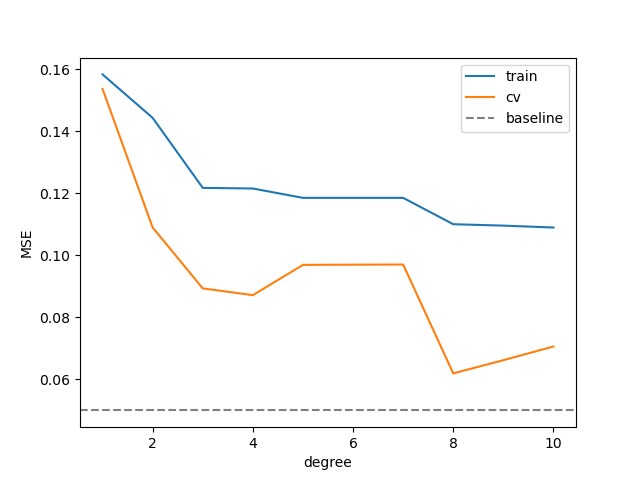

In [3]:
degrees = range(1,11)
train_mses = []
cv_mses = []

for degree in degrees:
    poly = PolynomialFeatures(degree,include_bias=False)
    X_train_mapped = poly.fit_transform(x_train)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_mapped)

    model = LinearRegression()
    model.fit(X_train_scaled,y_train)

    yhat_train = model.predict(X_train_scaled)
    train_mse = mean_squared_error(y_train,yhat_train)/2
    train_mses.append(train_mse)

    x_cv_scaled = scaler.transform(poly.transform(x_cv))
    yhat_cv = model.predict(x_cv_scaled)
    cv_mses.append(mean_squared_error(y_cv,yhat_cv)/2)

plt.plot(degrees, train_mses, label='train')
plt.plot(degrees, cv_mses, label='cv')
plt.axhline(baseline, color='gray', linestyle='--', label='baseline')
plt.xlabel('degree')
plt.ylabel('MSE')
plt.legend()
plt.savefig("bias_variance_degree.png")
plt.close()
from IPython.display import Image
Image("bias_variance_degree.png")

### Fixing high variance
If CV error is much higher than training error, the model is overfitting. Increasing the regularization strength (lambda) should reduce CV error by discouraging overly large weights.

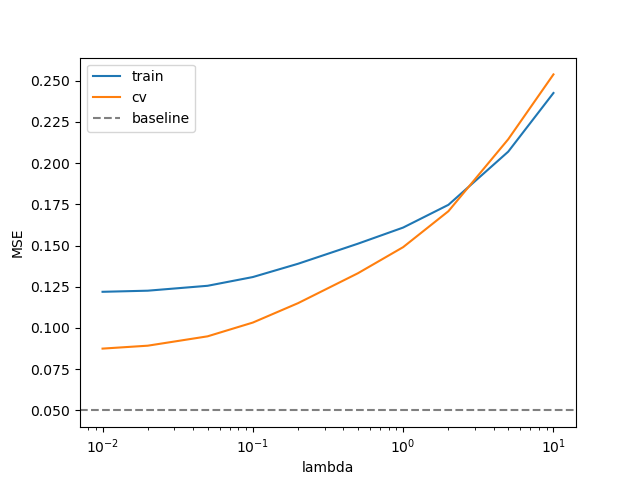

In [5]:
poly = PolynomialFeatures(4, include_bias=False)
X_train_mapped = poly.fit_transform(x_train)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_mapped)
X_cv_scaled = scaler.transform(poly.transform(x_cv))

reg_params = [0.01, 0.02, 0.05, 0.1, 0.2, 0.5, 1, 2, 5, 10]
train_mses_reg = []
cv_mses_reg = []

for lam in reg_params:    #lambda 
    model = Ridge(alpha=lam)
    model.fit(X_train_scaled, y_train)

    yhat_train = model.predict(X_train_scaled)
    train_mses_reg.append(mean_squared_error(y_train, yhat_train)/2)

    yhat_cv = model.predict(X_cv_scaled)
    cv_mses_reg.append(mean_squared_error(y_cv, yhat_cv)/2)

plt.plot(reg_params, train_mses_reg, label='train')
plt.plot(reg_params, cv_mses_reg, label='cv')
plt.axhline(baseline, color='gray', linestyle='--', label='baseline')
plt.xscale('log')
plt.xlabel('lambda')
plt.ylabel('MSE')
plt.legend()
plt.savefig("bias_variance_lambda.png")
plt.close()
from IPython.display import Image
Image("bias_variance_lambda.png")

### Summary
This lab used training vs cross-validation error, compared against a baseline, to diagnose bias and variance. Increasing polynomial degree reduced high bias by letting the model fit more complex patterns. Increasing regularization (lambda) is the fix for high variance, but only when variance is actually the problem — as seen here, adding regularization to a model that wasn't overfitting just introduced high bias instead.